In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.models as models


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

# Turning the images in the CroppedImages directory into a dataset
imagePath="D:/SeniorProject/nbaImageDataset1.pt"
dataset = torch.load(imagePath, weights_only=False)

# Creating an 80/20 training/test split
trainSplit = int(.8 * len(dataset))
testSplit = len(dataset) - trainSplit
trainDataset, testDataset = torch.utils.data.random_split(dataset, [trainSplit, testSplit])
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=True)



In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Methods for Pretraining, Training, and Evaluation**

In [4]:
def evaluateModel(model, testLoader):

  model.to(device)
  model.eval()
  correct = 0
  total = 0
  # Testing predictions on test set generated earlier and returning the accuracy
  with torch.no_grad():
    for images, labels in testLoader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  accuracy = 100 * correct / total
  return accuracy

In [14]:
def pretrainModel(model, numEpochs = 10, batchSize = 16, learningRate = 0.001):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

    trainPath = "D:/SeniorProject/tiny-imagenet-200/train"
    valPath = "D:/SeniorProject/tiny-imagenet-200/val"

    trainDataset = ImageFolder(trainPath, transform=transform)
    valDataset = ImageFolder(valPath, transform=transform)

    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learningRate)
    criterion = nn.CrossEntropyLoss()

    bestWeights = model.state_dict()
    bestAccuracy = 0

    for epoch in range(numEpochs):
        print(f"Epoch {epoch + 1} / {numEpochs}")
        model.train()
        runningLoss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainLoader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            runningLoss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Debugging information
            if i % 10 == 0:
                print(f"Batch {i}, Loss: {loss.item()}, Correct: {correct}, Total: {total}")


        trainLoss = runningLoss / len(trainLoader.dataset)
        trainAccuracy = correct / total
        print(f"Train Loss: {trainLoss:.4f}, Train Accuracy: {trainAccuracy:.4f}")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for data in valLoader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        valAccuracy = correct / total
        print(f"Validation Accuracy: {valAccuracy:.4f}")

        if valAccuracy > bestAccuracy:
            bestAccuracy = valAccuracy
            bestWeights = model.state_dict()
    
    print(f"Pretraining Complete.")
    model.load_state_dict(bestWeights)
    return model

In [16]:
torch.cuda.empty_cache()

# Reset CUDA memory statistics
torch.cuda.reset_max_memory_allocated()
torch.cuda.reset_max_memory_cached()

# Check GPU memory usage
print(torch.cuda.memory_summary(device=device, abbreviated=True))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 151773 KiB | 151773 KiB | 214267 KiB |  62494 KiB |
|---------------------------------------------------------------------------|
| Active memory         | 151773 KiB | 151773 KiB | 214267 KiB |  62494 KiB |
|---------------------------------------------------------------------------|
| Requested memory      | 151149 KiB | 151149 KiB | 213022 KiB |  61873 KiB |
|---------------------------------------------------------------

In [17]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 30)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [7]:
model = pretrainModel(model)

Epoch 1 / 10


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


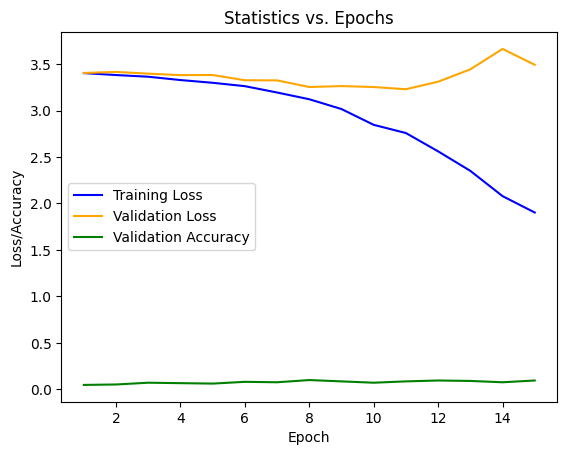

In [19]:
numEpochs = 15
trainLosses = []
trainAccuracies = []
validLosses = []
validAccuracies = []

for epoch in range(numEpochs): 
    model.train()
    running_loss = 0.0
    correct = total = 0

    for i, data in enumerate(trainLoader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    trainLosses.append(running_loss / len(trainLoader))
    trainAccuracies.append(correct / total)

    model.eval()

    valLoss = 0
    correct = total = 0
    with torch.no_grad():
        for data in testLoader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valLoss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    validLosses.append(valLoss / len(testLoader))
    validAccuracies.append(correct / total)


plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.title("Statistics vs. Epochs")
plt.legend()
plt.show()


# **Early Model Evaluation**

In [23]:
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

Accuracy: 9.5238%


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # Convolutional Layer
            nn.ReLU(),                                  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),      # Pooling Layer
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # Convolutional Layer
            nn.ReLU(),                                  # Activation function
            nn.MaxPool2d(kernel_size=2, stride=2),      # Pooling Layer
            nn.Flatten(),                               # Flatten the output to feed to fully connected layers
            nn.Linear(32 * 56 * 56, 128),               # Fully Connected Layer (adjust based on input size)
            nn.ReLU(),                                  # Activation function
            nn.Linear(128, 30)                          # Output Layer (for 30 classes)
        )
    
    def forward(self, x):
        return self.model(x)

# Example usage:
model = SimpleCNN().to(device)

SimpleCNN(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=100352, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=30, bias=True)
  )
)

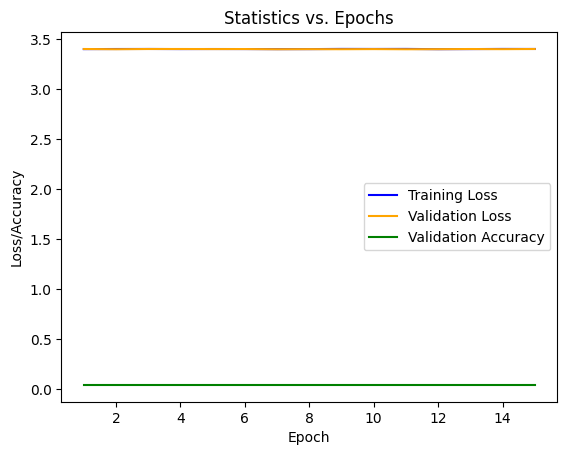

In [30]:
numEpochs = 15
trainLosses = []
trainAccuracies = []
validLosses = []
validAccuracies = []

for epoch in range(numEpochs): 
    model.train()
    running_loss = 0.0
    correct = total = 0

    for i, data in enumerate(trainLoader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    trainLosses.append(running_loss / len(trainLoader))
    trainAccuracies.append(correct / total)

    model.eval()

    valLoss = 0
    correct = total = 0
    with torch.no_grad():
        for data in testLoader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valLoss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    validLosses.append(valLoss / len(testLoader))
    validAccuracies.append(correct / total)


plt.plot(range(1, numEpochs + 1), trainLosses, label="Training Loss", color="blue")
plt.plot(range(1, numEpochs + 1), validLosses, label="Validation Loss", color="orange")
plt.plot(range(1, numEpochs + 1), validAccuracies, label="Validation Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.title("Statistics vs. Epochs")
plt.legend()

In [31]:
accuracy = evaluateModel(model, testLoader)
print(f"Accuracy: {accuracy:.4f}%")

Accuracy: 4.2857%
